# Signal level across minutes-bands — performance signals (X) by exposure _(population)_
_Read-only: how each signal's typical level sits across the minutes bands (cameo to full game), by position — the X-side partner to `target_by_band.ipynb`._

**Sections:** (a) signal distribution across bands · (b) which signals rise with minutes

---

## Setup
> Whole season, `minutes > 0`, DGW excluded; split the minutes axis into the rule-aligned bands `1-29 / 30-59 / 60+` and profile each signal within them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.kernels.descriptive.block_distributions import (
    compute_signal_block_distributions,
)

try:
    _result = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _result = load_mart()

STUDY_GW_MIN = 1
STUDY_GW_MAX = _result.data_cutoff_gw

mart = _result.mart
df = mart[mart["gw"].between(STUDY_GW_MIN, STUDY_GW_MAX)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()
df = df[df["is_dgw"] == False].copy()   # DGW excluded for now (single-fixture axis)

POSITIONS = ["GK", "DEF", "MID", "FWD"]

# Minutes-bands are the blocks here (cameo -> full game).
# compute_signal_block_distributions bins by whatever column we pass as gw_column,
# so we pass `minutes` and band ranges. Bands collapse at 60+ because FPL does not
# distinguish 60-89 from 90 (same appearance / clean-sheet regime); with DGW
# excluded, 60+ is a single full match (top bound 999 is just a safe ceiling).
MINUTES_BANDS = {"1-29": (1, 29), "30-59": (30, 59), "60+": (60, 999)}
BAND_ORDER = ["1-29", "30-59", "60+"]

# Raw performance-signal universe (numeric per-GW signals; exclude identity /
# market / structural / context / rolling). Also excluded:
#  - `starts`: a near-mechanical minutes proxy (deferred axis);
#  - `ict_index` (= influence+creativity+threat) and `xgi` (= xg+xa): EXACT
#    composites of signals we keep, so they add zero information -- we keep the
#    granular parts instead (no signal lost). `defensive_contribution` is NOT an
#    exact sum of its parts (r~0.81), so it and its parts are all kept.
_EXCLUDE = {
    "player_id", "gw", "position_code", "team_id",
    "purchase_price", "minutes", "total_points", "starts",
    "ict_index", "xgi",
    "is_bgw", "is_dgw", "is_warmup_gw",
    "fdr_avg", "xgc", "home_count", "away_count", "fixture_count",
    "is_live", "is_next", "is_previous", "finished",
    "transfers_in", "transfers_out", "ownership_count",
}
SIGNALS = sorted(
    c for c in df.select_dtypes(include="number").columns
    if c not in _EXCLUDE and "_roll" not in c and not c.endswith("_trend")
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.3f}".format)

print(f"Study range: GW {STUDY_GW_MIN} - GW {STUDY_GW_MAX} (whole season, from mart data_cutoff_gw)")
print(f"Population: minutes > 0, DGW excluded (participation, not a performance gate), n = {len(df):,} player-gameweeks")
print("Minutes-bands:", MINUTES_BANDS)
print(f"Signals ({len(SIGNALS)}):", SIGNALS)

Study range: GW 1 - GW 38 (whole season, from mart data_cutoff_gw)
Population: minutes > 0, DGW excluded (participation, not a performance gate), n = 11,190 player-gameweeks
Minutes-bands: {'1-29': (1, 29), '30-59': (30, 59), '60+': (60, 999)}
Signals (21): ['assists', 'bonus', 'bps', 'clean_sheets', 'clearances_blocks_interceptions', 'creativity', 'defensive_contribution', 'goals_conceded', 'goals_scored', 'influence', 'own_goals', 'penalties_missed', 'penalties_saved', 'recoveries', 'red_cards', 'saves', 'tackles', 'threat', 'xa', 'xg', 'yellow_cards']


## Signal classification — formula inputs vs leading indicators
Signal class governs how to read the profiles: **formula inputs** (direct FPL scoring components) are valid as univariate description here but never for same-gameweek association with `total_points` (tautological); **leading indicators** (process proxies, not in the formula) are valid for both and carry forward to `signal_target_association.ipynb`. The full taxonomy lives in `composition/signal_taxonomy.ipynb`.

In [2]:
FORMULA_INPUTS = {
    "goals_scored", "assists", "clean_sheets", "bonus", "bps",
    "saves", "penalties_saved", "penalties_missed", "own_goals",
    "yellow_cards", "red_cards", "goals_conceded",
}

formula_in_scope = [s for s in SIGNALS if s in FORMULA_INPUTS]
leading_in_scope = [s for s in SIGNALS if s not in FORMULA_INPUTS]

print(f"Formula inputs ({len(formula_in_scope)}) — univariate profiles valid; not for association with Y:")
print(f"  {formula_in_scope}")
print(f"\nLeading indicators ({len(leading_in_scope)}) — valid for profiles and association analysis:")
print(f"  {leading_in_scope}")

Formula inputs (12) — univariate profiles valid; not for association with Y:
  ['assists', 'bonus', 'bps', 'clean_sheets', 'goals_conceded', 'goals_scored', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'saves', 'yellow_cards']

Leading indicators (9) — valid for profiles and association analysis:
  ['clearances_blocks_interceptions', 'creativity', 'defensive_contribution', 'influence', 'recoveries', 'tackles', 'threat', 'xa', 'xg']


## (a) Signal distribution across minutes-bands, by position
> Determine how each signal's typical level sits across minutes-bands — does it rise with minutes on the pitch, or stay flat?

Each (signal, position) signal's median / IQR / p90 within each band (`1-29` to `60+`) via `compute_signal_block_distributions` binning on `minutes`; `n` per cell is shown so thin bands are visible. Reading a row left-to-right shows whether the typical level builds with time on the pitch — season-pooled, DGW excluded, with no claim about *why*.

In [3]:
band_dist = compute_signal_block_distributions(
    df, SIGNALS, POSITIONS, gw_column="minutes", gw_blocks=MINUTES_BANDS,
)
# NOTE: the kernel is generic -- here 'min_gw'/'max_gw' are the minute-band bounds,
# and 'block' is the band name. Order for readability.
band_dist["block"] = pd.Categorical(band_dist["block"], categories=BAND_ORDER, ordered=True)
band_dist["position"] = pd.Categorical(band_dist["position"], categories=POSITIONS, ordered=True)
band_dist["signal"] = pd.Categorical(band_dist["signal"], categories=SIGNALS, ordered=True)
band_dist = band_dist.sort_values(["signal", "position", "block"]).reset_index(drop=True)
display(
    band_dist[["signal", "position", "block", "n", "median", "iqr", "p90"]]
    .rename(columns={"block": "minutes_band"})
)

,signal,position,minutes_band,n,median,iqr,p90
0,assists,GK,1-29,4,NaN,NaN,NaN
1,assists,GK,30-59,6,NaN,NaN,NaN
2,assists,GK,60+,737,0.000,0.000,0.000
3,assists,DEF,1-29,618,0.000,0.000,0.000
4,assists,DEF,30-59,283,0.000,0.000,0.000
...,...,...,...,...,...,...,...
247,yellow_cards,MID,30-59,597,0.000,0.000,1.000
248,yellow_cards,MID,60+,3184,0.000,0.000,1.000
249,yellow_cards,FWD,1-29,504,0.000,0.000,0.000
250,yellow_cards,FWD,30-59,144,0.000,0.000,0.000


In [4]:
# Median-by-band pivot: read each (signal x position) row left-to-right to see how
# the signal's typical level moves from cameo (1-29) to full game (60+).
median_pivot = band_dist.pivot_table(
    index=["signal", "position"], columns="block", values="median", observed=True,
)[BAND_ORDER]
display(median_pivot.round(3))

block                  1-29  30-59   60+
signal       position                   
assists      GK         NaN    NaN 0.000
             DEF      0.000  0.000 0.000
             MID      0.000  0.000 0.000
             FWD      0.000  0.000 0.000
bonus        GK         NaN    NaN 0.000
...                     ...    ...   ...
xg           FWD      0.000  0.040 0.215
yellow_cards GK         NaN    NaN 0.000
             DEF      0.000  0.000 0.000
             MID      0.000  0.000 0.000
             FWD      0.000  0.000 0.000

[84 rows x 3 columns]

## (b) Which signals rise with minutes — per position
> Establish, per position, which signals move most from cameo to full-game appearances and which barely move.

Per position, the top-5 climbers by `Δmedian = median(60+) − median(1-29)` (horizontal bars); signals that don't move (Δ ≈ 0 — the rare-event stats whose median is 0 in every band) are listed beneath rather than plotted. There are no negative movers at any position, so nothing scores higher in cameos.

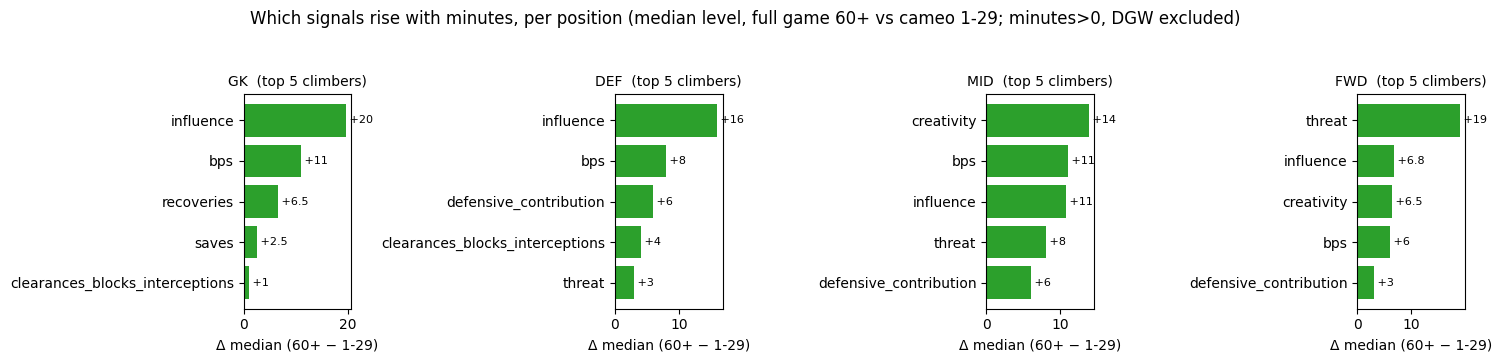

GK: flat (Δ≈0, do not move with minutes) — assists, penalties_saved, xg, xa, threat, tackles, red_cards, own_goals, penalties_missed, bonus, goals_scored, goals_conceded, defensive_contribution, creativity, clean_sheets, yellow_cards
DEF: flat (Δ≈0, do not move with minutes) — xa, assists, red_cards, xg, saves, own_goals, penalties_saved, penalties_missed, bonus, goals_scored, clean_sheets, yellow_cards
MID: flat (Δ≈0, do not move with minutes) — assists, red_cards, saves, own_goals, penalties_saved, penalties_missed, bonus, goals_scored, clean_sheets, yellow_cards
FWD: flat (Δ≈0, do not move with minutes) — xa, assists, red_cards, tackles, saves, own_goals, penalties_saved, penalties_missed, bonus, goals_scored, clean_sheets, yellow_cards


In [5]:
# Per-position climb: for EACH position, the signals whose typical level rises
# most from cameo (1-29) to full game (60+): Δmedian = median(60+) - median(1-29).
# Per position (NOT pooled) -- the signals are position-specific (a GK's saves and
# a FWD's threat are not comparable, and pooling buries them in zeros). Top-5
# climbers per position are plotted; the flat ones (Δ≈0) are listed beneath
# rather than plotted -- there are no negative movers.
def _bandname(mn):
    return "1-29" if mn < 30 else "30-59" if mn < 60 else "60+"

w = df.copy()
w["band"] = w["minutes"].astype(int).map(_bandname)
TOP_N = 5

fig, axes = plt.subplots(1, len(POSITIONS), figsize=(15, 3.4))
flat_by_pos = {}
for ax, pos in zip(axes, POSITIONS):
    med = w[w.position == pos].groupby("band")[SIGNALS].median().reindex(BAND_ORDER).astype(float)
    delta = (med.loc["60+"] - med.loc["1-29"]).sort_values(ascending=False)
    top = delta.head(TOP_N).iloc[::-1]            # reverse so the biggest is on top
    ax.barh(top.index, top.to_numpy(), color="#2ca02c")
    for y, v in enumerate(top.to_numpy()):
        ax.text(v, y, f" {v:+.2g}", va="center", fontsize=8)
    ax.set_title(f"{pos}  (top {TOP_N} climbers)", fontsize=10)
    ax.set_xlabel("Δ median (60+ − 1-29)")
    flat_by_pos[pos] = delta[delta.abs() < 0.05].index.tolist()
fig.suptitle("Which signals rise with minutes, per position "
             "(median level, full game 60+ vs cameo 1-29; minutes>0, DGW excluded)", y=1.05)
plt.tight_layout()
plt.show()

for pos in POSITIONS:
    print(f"{pos}: flat (Δ≈0, do not move with minutes) — {', '.join(flat_by_pos[pos])}")